# Final Assignment Part 1: Analyzing the Impact of Recession on Automobile Sales
### Visualizations using Matplotlib, Seaborn & Pandas

**Objective:** Analyze historical automobile sales data for XYZAutomotives to understand
how sales were affected during recession periods (1980, 1981-82, 1991, 2000-01, 2007-09, 2020).


## Step 0: Import libraries and load the dataset

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots render nicely inside the notebook
%matplotlib inline
sns.set_style("whitegrid")

In [6]:
# Load the dataset
# Replace this URL/path with the exact dataset link given in your lab instructions
# if it differs from the one below.
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

df = pd.read_csv(url)
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


In [8]:
# Quick look at the structure of the data
df.info()
print(df['Vehicle_Type'].unique())
print(df['Year'].min(), '-', df['Year'].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     528 non-null    object 
 1   Year                     528 non-null    int64  
 2   Month                    528 non-null    object 
 3   Recession                528 non-null    int64  
 4   Consumer_Confidence      528 non-null    float64
 5   Seasonality_Weight       528 non-null    float64
 6   Price                    528 non-null    float64
 7   Advertising_Expenditure  528 non-null    int64  
 8   Competition              528 non-null    int64  
 9   GDP                      528 non-null    float64
 10  Growth_Rate              528 non-null    float64
 11  unemployment_rate        528 non-null    float64
 12  Automobile_Sales         528 non-null    float64
 13  Vehicle_Type             528 non-null    object 
 14  City                     5

## TASK 1.1 — Line chart: Automobile sales fluctuation, year over year

We use pandas' built-in `.plot()` functionality (which wraps Matplotlib) to plot the
average yearly automobile sales, then annotate the recession years so the trend is
easy for the directors to interpret at a glance.

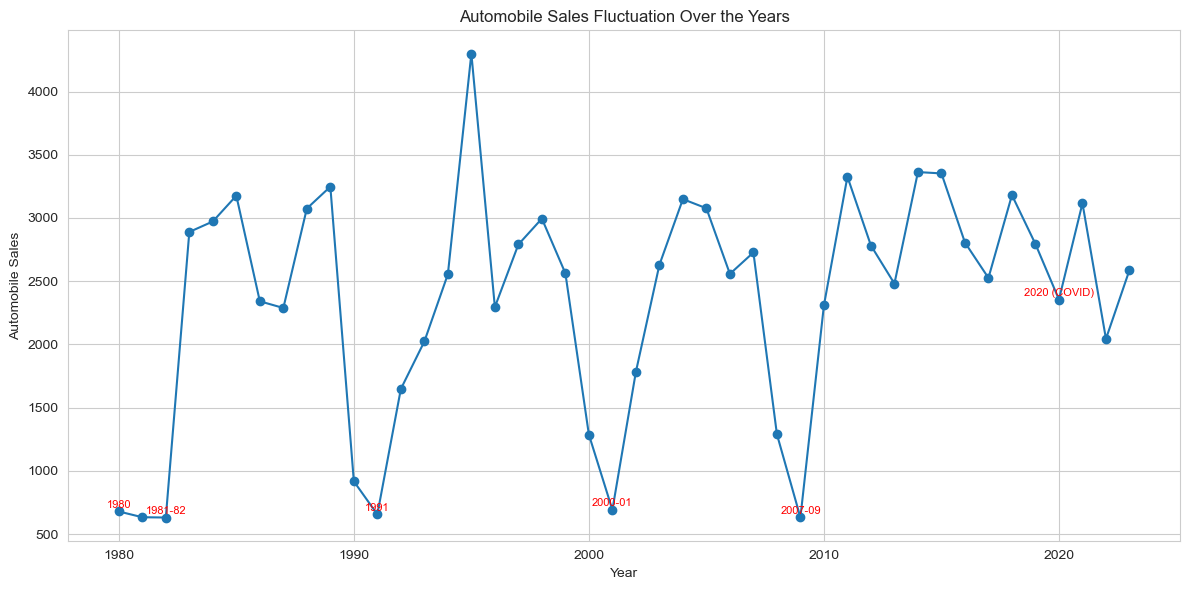

In [10]:
df_line = df.groupby('Year')['Automobile_Sales'].mean()

plt.figure(figsize=(12, 6))
df_line.plot(kind='line', marker='o')

plt.xlabel('Year')
plt.ylabel('Automobile Sales')
plt.title('Automobile Sales Fluctuation Over the Years')

# Annotate recession periods for context
recession_years = {1980: '1980', 1982: '1981-82', 1991: '1991',
                    2001: '2000-01', 2009: '2007-09', 2020: '2020 (COVID)'}
for yr, label in recession_years.items():
    if yr in df_line.index:
        plt.annotate(label, xy=(yr, df_line[yr]), xytext=(yr, df_line[yr] + 30),
                     fontsize=8, color='red', ha='center')

plt.tight_layout()
plt.show()

## TASK 1.2 — Advertising expenditure vs. automobile sales (non-recession periods)

To see how advertising spend tracks with sales when the economy is healthy, we filter
to `Recession == 0`, then plot both series over time on a dual y-axis line chart
(since they're on very different scales).

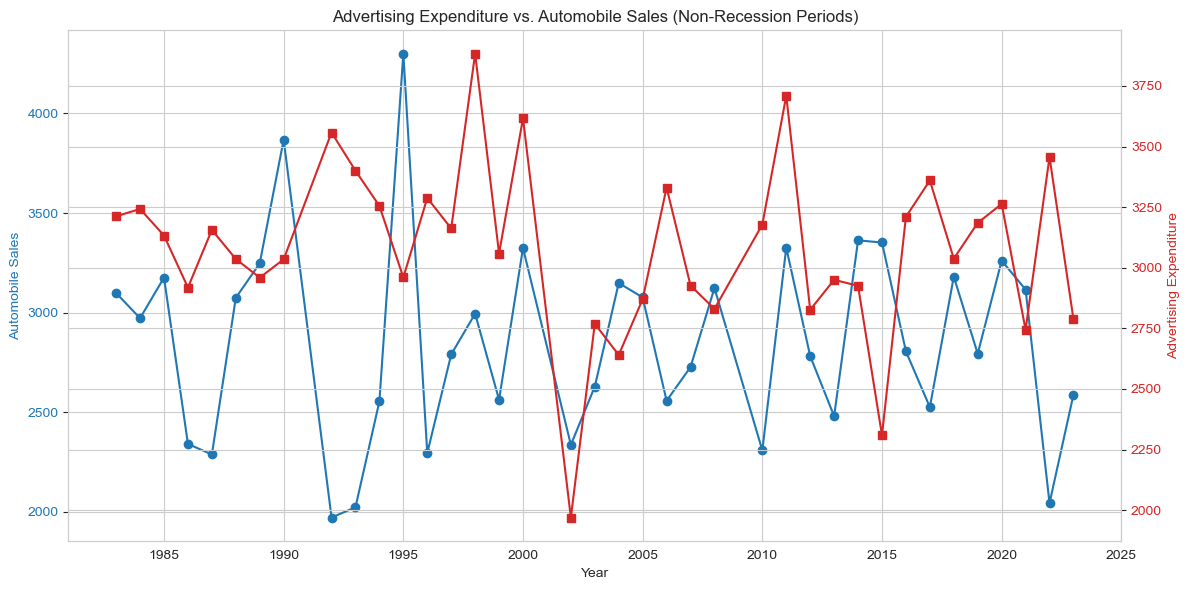

In [12]:
non_rec_data = df[df['Recession'] == 0]

yearly_non_rec = non_rec_data.groupby('Year').agg(
    {'Automobile_Sales': 'mean', 'Advertising_Expenditure': 'mean'}
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(yearly_non_rec['Year'], yearly_non_rec['Automobile_Sales'],
         color='tab:blue', marker='o', label='Automobile Sales')
ax1.set_xlabel('Year')
ax1.set_ylabel('Automobile Sales', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(yearly_non_rec['Year'], yearly_non_rec['Advertising_Expenditure'],
         color='tab:red', marker='s', label='Advertising Expenditure')
ax2.set_ylabel('Advertising Expenditure', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Advertising Expenditure vs. Automobile Sales (Non-Recession Periods)')
fig.tight_layout()
plt.show()

**Insight:** During non-recession periods, advertising expenditure and automobile
sales tend to move in the same general direction — when the company invests more in
advertising, sales trend upward too, suggesting advertising spend is an effective lever
to pull in healthy economic conditions.

## TASK 1.3 — Seaborn: Sales trend per vehicle type, recession vs. non-recession

A grouped bar chart makes it easy to compare each vehicle type's average sales
side-by-side across the two states of the economy.

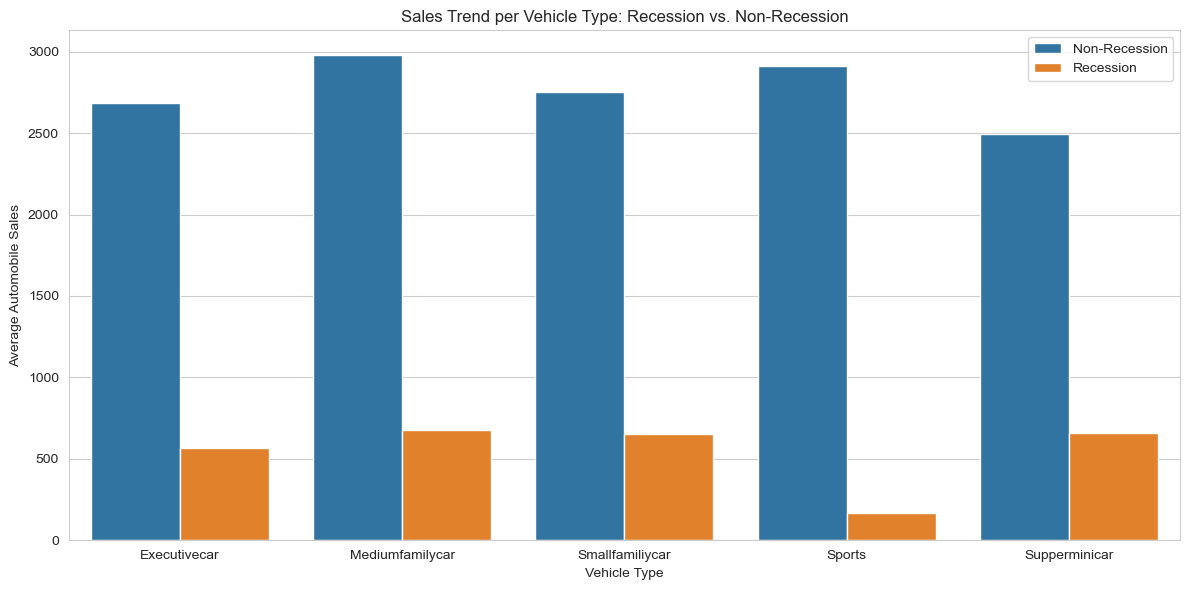

In [14]:
vehicle_sales = df.groupby(['Vehicle_Type', 'Recession'])['Automobile_Sales'].mean().reset_index()
vehicle_sales['Recession'] = vehicle_sales['Recession'].map({0: 'Non-Recession', 1: 'Recession'})

plt.figure(figsize=(12, 6))
sns.barplot(data=vehicle_sales, x='Vehicle_Type', y='Automobile_Sales', hue='Recession')

plt.xlabel('Vehicle Type')
plt.ylabel('Average Automobile Sales')
plt.title('Sales Trend per Vehicle Type: Recession vs. Non-Recession')
plt.legend(title='')
plt.tight_layout()
plt.show()

## TASK 1.4 — Subplots: GDP variation, recession vs. non-recession

Two side-by-side line plots let the directors compare the shape of GDP over time
in each economic state without one chart overpowering the other on scale.

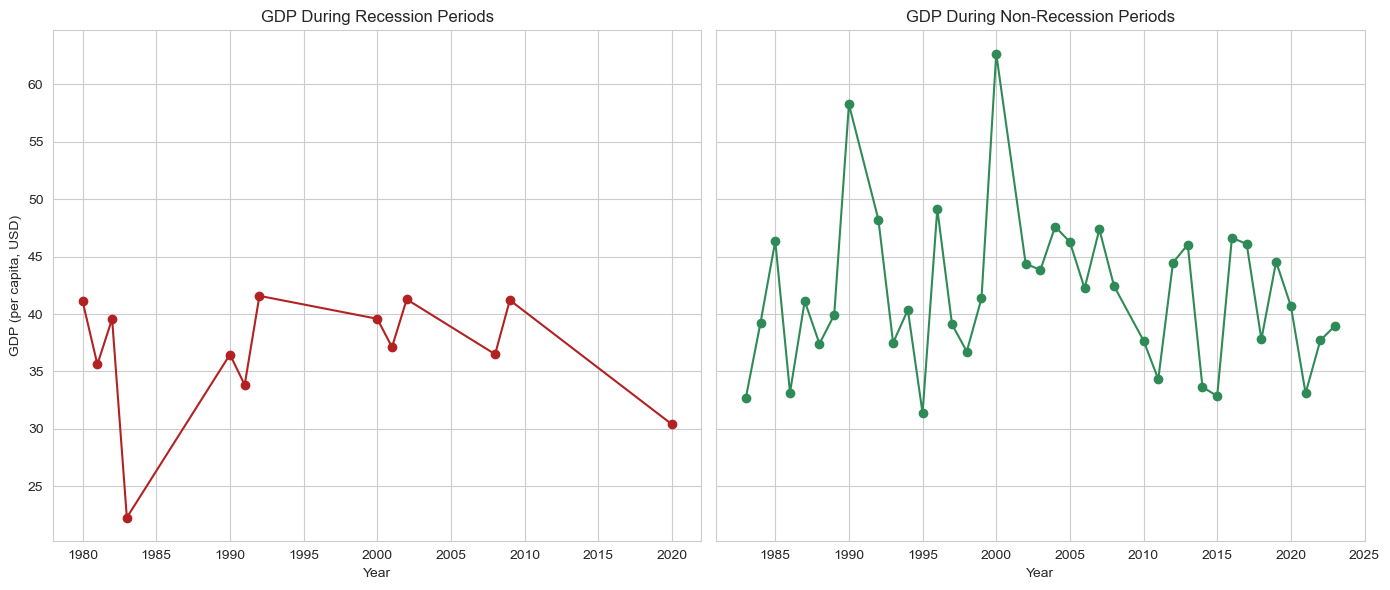

In [16]:
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axs[0].plot(rec_data.groupby('Year')['GDP'].mean(), color='firebrick', marker='o')
axs[0].set_title('GDP During Recession Periods')
axs[0].set_xlabel('Year')
axs[0].set_ylabel('GDP (per capita, USD)')

axs[1].plot(non_rec_data.groupby('Year')['GDP'].mean(), color='seagreen', marker='o')
axs[1].set_title('GDP During Non-Recession Periods')
axs[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

## TASK 1.5 — Bubble plot: Impact of seasonality on automobile sales

In a bubble plot, the size of each point encodes a third variable. Here, bubble size
represents `Seasonality_Weight`, so months with a stronger seasonal boost appear as
larger bubbles.

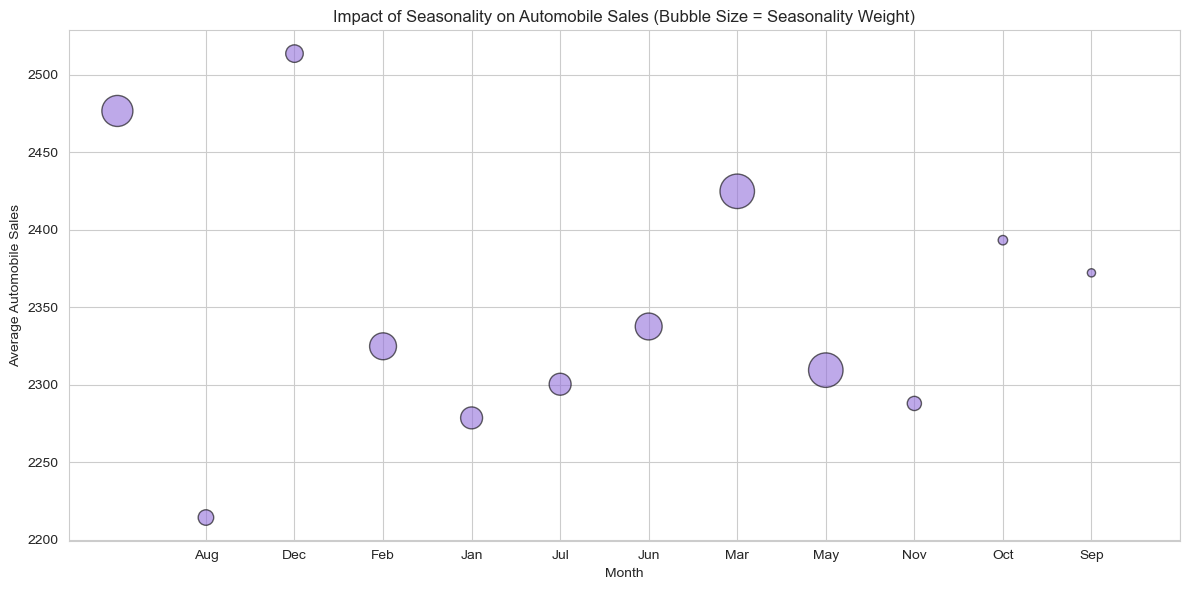

In [18]:
seasonality_data = df.groupby('Month').agg(
    {'Automobile_Sales': 'mean', 'Seasonality_Weight': 'mean'}
).reset_index()

plt.figure(figsize=(12, 6))
plt.scatter(seasonality_data['Month'], seasonality_data['Automobile_Sales'],
            s=seasonality_data['Seasonality_Weight'] * 500,
            alpha=0.6, color='mediumpurple', edgecolors='black')

plt.xlabel('Month')
plt.ylabel('Average Automobile Sales')
plt.title('Impact of Seasonality on Automobile Sales (Bubble Size = Seasonality Weight)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## TASK 1.6 — Matplotlib scatter plot: Price vs. sales volume during recessions

A plain scatter plot is the clearest way to check for a correlation between two
continuous variables — here, average vehicle price and sales volume, restricted to
recession periods only.

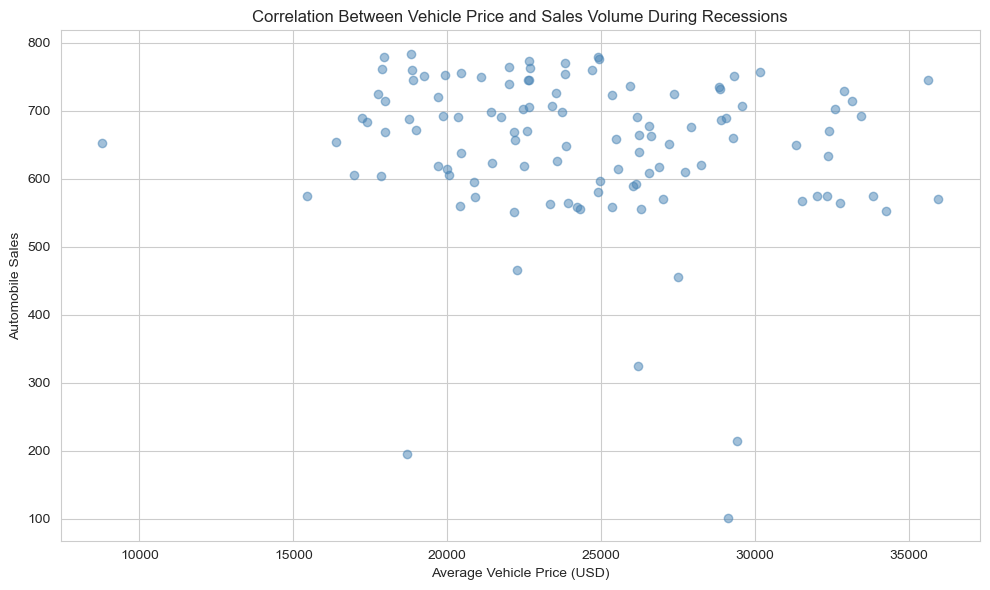

Correlation coefficient: -0.147


In [20]:
rec_data = df[df['Recession'] == 1]

plt.figure(figsize=(10, 6))
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'], alpha=0.5, color='steelblue')

plt.xlabel('Average Vehicle Price (USD)')
plt.ylabel('Automobile Sales')
plt.title('Correlation Between Vehicle Price and Sales Volume During Recessions')
plt.tight_layout()
plt.show()

# Quick numeric check of the correlation
corr = rec_data['Price'].corr(rec_data['Automobile_Sales'])
print(f"Correlation coefficient: {corr:.3f}")

**Insight:** A negative correlation here would indicate that during recessions,
higher-priced vehicles see comparatively lower sales volumes — consumers likely shift
toward cheaper options when budgets tighten.

## TASK 1.7 — Pie chart: Advertising expenditure, recession vs. non-recession

A pie chart is well suited to showing how a single total (advertising spend) splits
between exactly two categories.

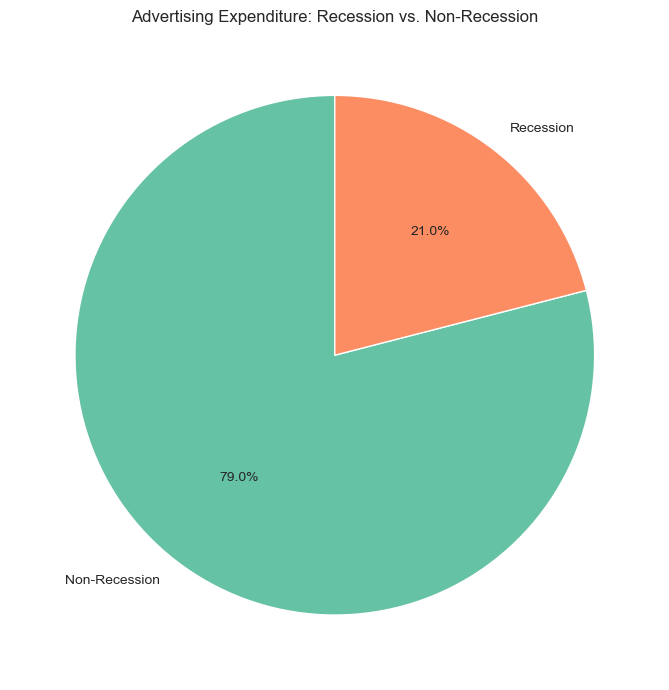

In [22]:
exp_data = df.groupby('Recession')['Advertising_Expenditure'].sum()

plt.figure(figsize=(7, 7))
plt.pie(exp_data, labels=['Non-Recession', 'Recession'], autopct='%1.1f%%',
        startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title('Advertising Expenditure: Recession vs. Non-Recession')
plt.tight_layout()
plt.show()

## TASK 1.8 — Pie chart: Advertising expenditure by vehicle type (recession period)

Same idea as Task 1.7, but now we break the recession-period spend down by vehicle
type to see where the company directed its advertising budget when times were tough.

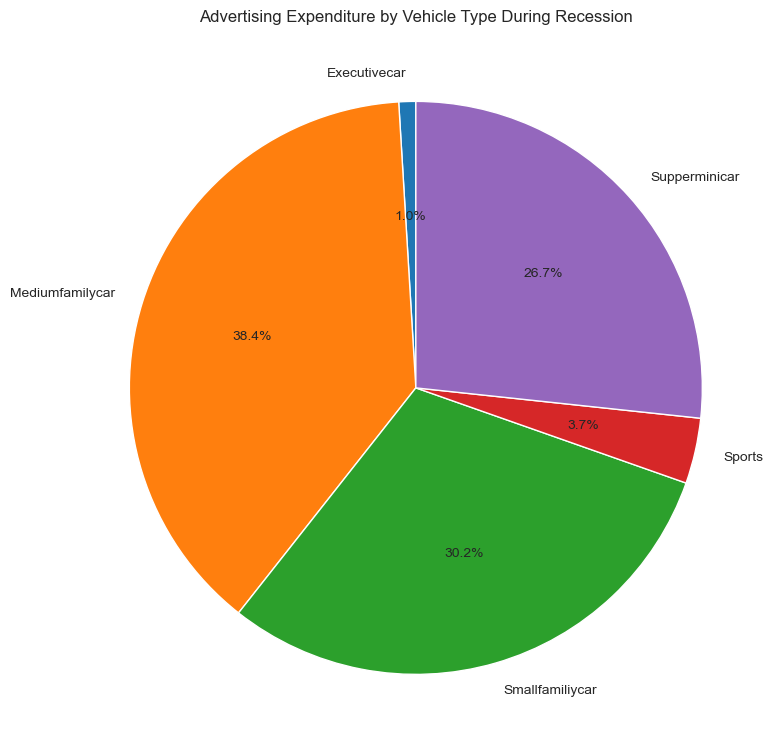

In [24]:
rec_exp_by_type = rec_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
plt.pie(rec_exp_by_type, labels=rec_exp_by_type.index, autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure by Vehicle Type During Recession')
plt.tight_layout()
plt.show()

## TASK 1.9 — Line chart: Effect of unemployment rate on vehicle type and sales (recession period)

We group recession-period data by unemployment rate and vehicle type, then plot a
separate line per vehicle type so the directors can see whether some vehicle
categories are more sensitive to rising unemployment than others.

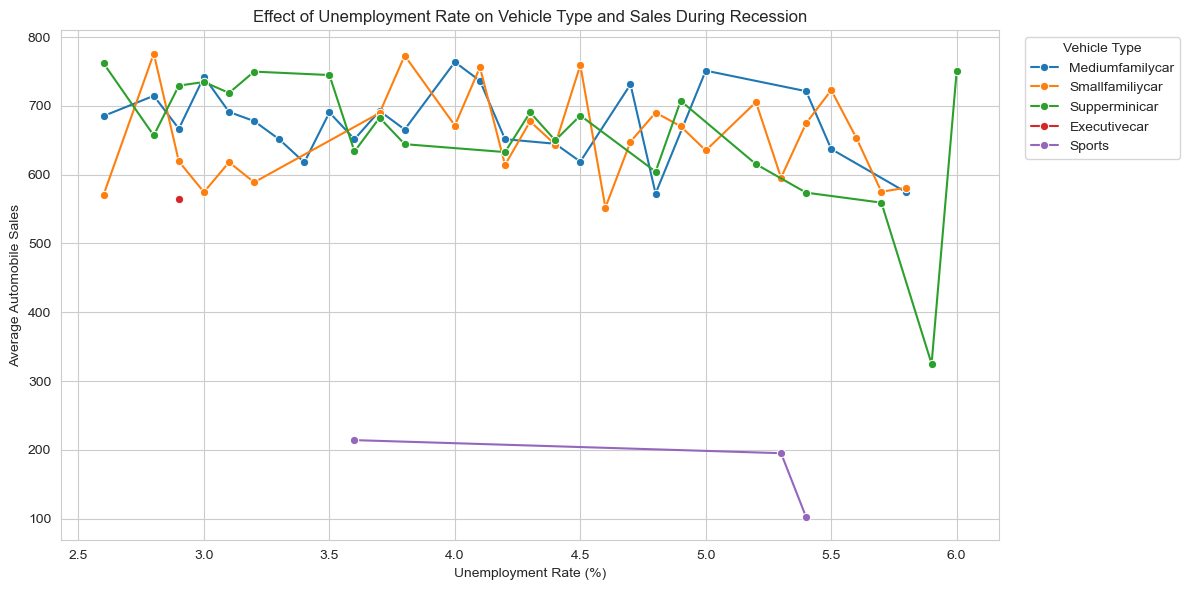

In [26]:
unemp_data = rec_data.groupby(['unemployment_rate', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=unemp_data, x='unemployment_rate', y='Automobile_Sales',
             hue='Vehicle_Type', marker='o')

plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Average Automobile Sales')
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales During Recession')
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()